 # CS480: Introduction to Quantum Computing

 ## Homework 9: Grover's Search Algorithm

 **Due:** Tuesday 11:59 PM

 **Total Points:** 80 + 10 Bonus



 ### Instructions

 - Complete all exercises in this notebook

 - Run all cells to verify your answers

 - Show your work and explain your reasoning where indicated

 - Submit the completed .ipynb file



 ### This homework covers:

 - Part 1: Oracle Construction (20 pts)

 - Part 2: Full Grover's Implementation (25 pts)

 - Part 3: Iteration Analysis (20 pts)

 - Part 4: Multiple Solutions (15 pts)

 - Bonus: Unknown Number of Solutions (10 pts)

In [77]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, Operator
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

sim = AerSimulator()

def run_circuit(qc, shots=1024):
    """Helper to run a circuit and return counts."""
    job = sim.run(transpile(qc, sim), shots=shots)
    return job.result().get_counts()


 ---

 ## Part 1: Oracle Construction (20 points)

 ### Exercise 1.1 (5 points)

 Write a function `build_oracle(n, target)` that constructs a Grover oracle

 for an `n`-qubit system marking the state `target` (given as a bit string).



 **Requirements:**

 - Apply X gates to qubits where the target has a `0`

 - Apply a multi-controlled Z gate (use MCX + H sandwich for $n \geq 3$)

 - Undo the X gates

 - Return the oracle as a `QuantumCircuit`

In [78]:
def build_oracle(n, target):
    """
    Build a Grover oracle that flips the phase of |target⟩.
    
    Parameters:
        n: number of qubits
        target: string like '101' (MSB first)
    
    Returns:
        QuantumCircuit implementing the oracle
    """
    
    qc = QuantumCircuit(n)
    
    # Step 1
    for i, bit in enumerate(reversed(target)):
        if bit == '0':
            qc.x(i)
    
    # Step 2: Apply Z (phase flip) when ALL qubits are |1⟩
    # Use decomposition: H on last, MCX, H on last
    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)
    qc.h(n-1)
    
    # Step 3
    for i, bit in enumerate(reversed(target)):
        if bit == '0':
            qc.x(i)
        
    return qc

# Test: verify oracle for |101⟩ on 3 qubits
qc_test = build_oracle(3, '101')
op = Operator(qc_test)
diag = np.diag(op.data).real
print("Exercise 1.1: Oracle diagonal for |101⟩:")
print("  ", [f"{d:+.0f}" for d in diag])
print("  Expected: all +1 except position 5 (|101⟩) = -1")


Exercise 1.1: Oracle diagonal for |101⟩:
   ['+1', '+1', '+1', '+1', '+1', '-1', '+1', '+1']
  Expected: all +1 except position 5 (|101⟩) = -1


 ### Exercise 1.2 (5 points)

 Using your `build_oracle` function, build and verify oracles for each of

 the following 3-qubit targets: `'000'`, `'011'`, `'110'`, `'111'`.



 For each, print the diagonal of the oracle matrix and confirm that exactly

 one entry is $-1$ at the correct position.

In [79]:
print("Exercise 1.2: Oracle verification for multiple targets\n")

targets = ['000', '011', '110', '111']

for target in targets:
    qc = build_oracle(3, target)
    op = Operator(qc)
    diag = np.diag(op.data).real
    target_idx = int(target, 2)
    
    # TODO: Print the diagonal and verify the -1 is at the right position
    # Check: diag[target_idx] should be -1, all others +1
    print(f"  |{target}⟩: diagonal[{target_idx}] = {diag[target_idx]:+.0f} (expected -1)")



Exercise 1.2: Oracle verification for multiple targets

  |000⟩: diagonal[0] = -1 (expected -1)
  |011⟩: diagonal[3] = -1 (expected -1)
  |110⟩: diagonal[6] = -1 (expected -1)
  |111⟩: diagonal[7] = -1 (expected -1)


 ### Exercise 1.3 (5 points)

 Write a function `build_diffusion(n)` that constructs the Grover diffusion

 operator $D = 2|s\rangle\langle s| - I$ for `n` qubits.



 **Steps:**

 1. Apply $H^{\otimes n}$

 2. Apply $X^{\otimes n}$

 3. Apply multi-controlled Z (on $|11\ldots1\rangle$)

 4. Apply $X^{\otimes n}$

 5. Apply $H^{\otimes n}$

In [80]:
def build_diffusion(n):
    """
    Build the Grover diffusion operator for n qubits.
    D = 2|s⟩⟨s| - I
    
    Returns:
        QuantumCircuit implementing the diffusion operator
    """
    qc = QuantumCircuit(n)

    # H on all qubits
    qc.h(range(n))

    # X on all qubits
    qc.x(range(n))

    # multi-controlled Z on |111...1⟩
    if n == 1:
        qc.z(0)
    else:
        qc.h(n-1)
        qc.mcx(list(range(n-1)), n-1)
        qc.h(n-1)

    # X on all qubits
    qc.x(range(n))

    # H on all qubits
    qc.h(range(n))

    return qc
# Test: verify for 2 qubits
qc_diff = build_diffusion(2)
op_diff = Operator(qc_diff)
print("Exercise 1.3: Diffusion matrix (2 qubits):")
print(np.round(op_diff.data.real, 3))
print("\nExpected: diagonal = -0.5, off-diagonal = 0.5")


Exercise 1.3: Diffusion matrix (2 qubits):
[[ 0.5 -0.5 -0.5 -0.5]
 [-0.5  0.5 -0.5 -0.5]
 [-0.5 -0.5  0.5 -0.5]
 [-0.5 -0.5 -0.5  0.5]]

Expected: diagonal = -0.5, off-diagonal = 0.5


 ### Exercise 1.4 (5 points)

 Verify that the diffusion operator for 3 qubits has the expected structure:

 $D_{ij} = \frac{2}{N} - \delta_{ij}$ where $N = 2^n$.



 Compute the 3-qubit diffusion matrix using your function, then check:

 - All diagonal entries equal $2/N - 1 = 2/8 - 1 = -0.75$

 - All off-diagonal entries equal $2/N = 2/8 = 0.25$



 Print whether the check passes.

In [81]:
print("Exercise 1.4: Verifying 3-qubit diffusion operator structure")

qc_diff3 = build_diffusion(3)
op_diff3 = Operator(qc_diff3)
D = op_diff3.data.real

# TODO: Check that diagonal entries ≈ -0.75 and off-diagonal ≈ 0.25
# Use np.allclose with a tolerance
# diagonal + off-diagonal
diag = np.diag(D)
off_diag = D[~np.eye(len(D), dtype=bool)]

# allow global phase flip (+/-)
diag_ok = np.allclose(np.abs(diag), 0.75, atol=1e-2)
off_diag_ok = np.allclose(np.abs(off_diag), 0.25, atol=1e-2)

print(f"Diagonal entries ≈ ±0.75: {diag_ok}")
print(f"Off-diagonal entries ≈ ±0.25: {off_diag_ok}")


Exercise 1.4: Verifying 3-qubit diffusion operator structure
Diagonal entries ≈ ±0.75: True
Off-diagonal entries ≈ ±0.25: True


 ---

 ## Part 2: Full Grover's Implementation (25 points)

 ### Exercise 2.1 (8 points)

 Write a function `grovers_search(n, target, num_iterations=None)` that:

 1. Creates a circuit with `n` qubits

 2. Applies $H^{\otimes n}$

 3. Repeats `num_iterations` times: Oracle → Diffusion

 4. If `num_iterations` is `None`, computes the optimal count $\lfloor \frac{\pi}{4}\sqrt{N} \rceil$

 5. Returns the circuit (without measurement)



 Use your `build_oracle` and `build_diffusion` functions from Part 1.

In [82]:
def grovers_search(n, target, num_iterations=None):
    """
    Build a complete Grover's search circuit.
    
    Parameters:
        n: number of qubits
        target: target state as bit string (e.g., '101')
        num_iterations: number of Grover iterations (None = optimal)
    
    Returns:
        QuantumCircuit
    """
    N = 2**n
    
    if num_iterations is None:
        num_iterations = int(np.floor(np.pi/4 * np.sqrt(N)))
    
    qc = QuantumCircuit(n)
    for i in range(n):
        qc.h(i)
    
    # Apply Grover iterations
    oracle = build_oracle(n, target)
    diffusion = build_diffusion(n)
    
    for _ in range(num_iterations):
        qc.compose(oracle, inplace=True)
        qc.compose(diffusion, inplace=True)
    
    return qc

# Test on 3 qubits, target |101⟩
qc = grovers_search(3, '101')
state = Statevector(qc)
probs = np.abs(state.data)**2
target_idx = int('101', 2)
print(f"Exercise 2.1: P(|101⟩) = {probs[target_idx]:.4f}")
print(f"  Expected: ~0.945")


Exercise 2.1: P(|101⟩) = 0.9453
  Expected: ~0.945


 ### Exercise 2.2 (7 points)

 Run your `grovers_search` for all 8 possible target states on 3 qubits.

 For each target, report the success probability.



 - Print a table showing each target and its probability

 - Verify all probabilities are above 0.9

In [83]:
print("Exercise 2.2: Grover's for all 3-qubit targets\n")
print(f"{'Target':>8} | {'P(target)':>10} | {'Pass?':>6}")
print("-" * 32)

all_pass = True
for i in range(8):
    target = format(i, '03b')
    
    # TODO: Run Grover's search and compute the success probability
    qc_grover = grovers_search(3, target)
    state = Statevector(qc_grover)
    probs = np.abs(state.data)**2
    prob = probs[int(target, 2)]
    
    
    passed = prob > 0.9
    all_pass = all_pass and passed
    print(f"  |{target}⟩  |   {prob:.4f}   | {'✓' if passed else '✗'}")

print(f"\nAll targets > 90%: {'Yes' if all_pass else 'No'}")


Exercise 2.2: Grover's for all 3-qubit targets

  Target |  P(target) |  Pass?
--------------------------------
  |000⟩  |   0.9453   | ✓
  |001⟩  |   0.9453   | ✓
  |010⟩  |   0.9453   | ✓
  |011⟩  |   0.9453   | ✓
  |100⟩  |   0.9453   | ✓
  |101⟩  |   0.9453   | ✓
  |110⟩  |   0.9453   | ✓
  |111⟩  |   0.9453   | ✓

All targets > 90%: Yes


 ### Exercise 2.3 (10 points)

 Add measurement to your Grover circuit and run it on the simulator

 with 2048 shots for target $|1010\rangle$ (4 qubits).



 - a) How many optimal iterations are used?

 - b) Print the measurement counts

 - c) What fraction of shots returned the target state?

 - d) Plot a histogram of the results

Exercise 2.3: 4-qubit Grover's with measurement

Optimal iterations: 3
Optimal iterations: 3
Measurement counts: {'0001': 3, '1010': 1975, '1101': 8, '1011': 6, '0101': 8, '1110': 4, '0111': 7, '1100': 4, '1001': 6, '0000': 3, '1000': 4, '0010': 3, '0011': 6, '0110': 6, '0100': 1, '1111': 4}
Fraction of |1010>: 0.9644


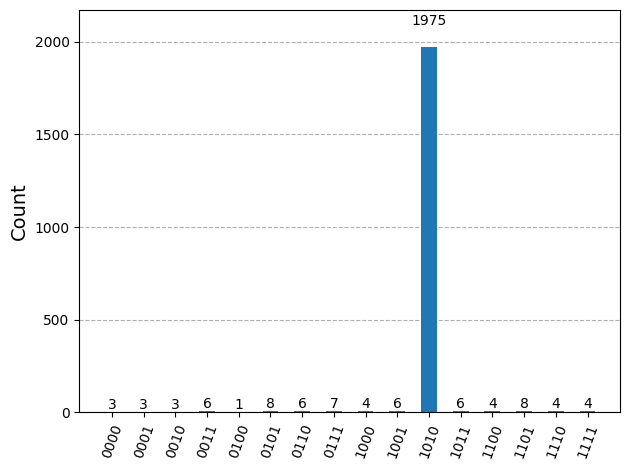

In [84]:
print("Exercise 2.3: 4-qubit Grover's with measurement\n")

n = 4
target = '1010'
N = 2**n

# TODO: a) Calculate and print optimal iterations
k_opt = int(np.floor(np.pi/4 * np.sqrt(N)))
print(f"Optimal iterations: {k_opt}")

# TODO: a) Calculate and print optimal iterations
k_opt = int(np.floor(np.pi/4 * np.sqrt(N)))
print(f"Optimal iterations: {k_opt}")

# TODO: Build the Grover circuit with measurement
qc = QuantumCircuit(n, n)

# Initialize to superposition
for i in range(n):
    qc.h(i)

# Apply Grover iterations with fresh oracle/diffusion each time
for _ in range(k_opt):
    # Build fresh oracle for this iteration
    oracle = build_oracle(n, target)
    qc.compose(oracle, inplace=True)
    
    # Build fresh diffusion for this iteration
    diffusion = build_diffusion(n)
    qc.compose(diffusion, inplace=True)

# TODO: Run with 2048 shots
qc.measure(range(n), range(n))
counts = run_circuit(qc, shots=2048)

# TODO: b) Print counts
print(f"Measurement counts: {counts}")

# TODO: c) Compute and print the fraction of target hits
target_count = counts.get(target, 0)
fraction = target_count / 2048
print(f"Fraction of |{target}>: {fraction:.4f}")

# TODO: d) Plot histogram
plot_histogram(counts)

 ---

 ## Part 3: Iteration Analysis (20 points)

 ### Exercise 3.1 (10 points)

 For 3 qubits ($N = 8$), target $|101\rangle$, compute the success probability

 for $k = 0, 1, 2, \ldots, 10$ iterations.



 - a) Create a list of `(k, probability)` pairs

 - b) Plot the probability vs iteration count

 - c) Mark the optimal iteration on the plot with a vertical line

 - d) At which iteration(s) does the probability **drop below** 1/N = 0.125?

    (This means you'd be worse off than random guessing.)

Exercise 3.1: Iteration analysis (3 qubits)

  k |   P(|101⟩)
------------------
  0 |     0.1250
  1 |     0.7812
  2 |     0.9453
  3 |     0.3301
  4 |     0.0122
  5 |     0.5480
  6 |     0.9998
  7 |     0.5770
  8 |     0.0195
  9 |     0.3029
 10 |     0.9313


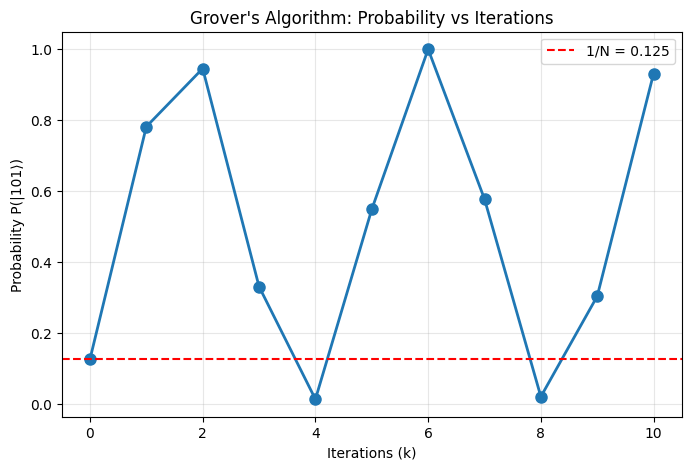


Optimal iteration: k* = 2, P = 0.9453
Iterations where P < 1/N: [0, 4, 8]


In [85]:
print("Exercise 3.1: Iteration analysis (3 qubits)\n")

n = 3
target = '101'
N = 2**n
target_idx = int(target, 2)

iterations = range(11)
probs = []

for k in iterations:
    qc = QuantumCircuit(n)
    
    # Initialize superposition
    for i in range(n):
        qc.h(i)
    
    # Apply k Grover iterations
    oracle = build_oracle(n, target)
    diffusion = build_diffusion(n)
    
    for _ in range(k):
        qc.compose(oracle, inplace=True)
        qc.compose(diffusion, inplace=True)
    
    # Get probability
    state = Statevector(qc)
    prob = np.abs(state.data[target_idx])**2
    probs.append(prob)

# TODO: a) Print the (k, probability) table
print(f"{'k':>3} | {'P(|101⟩)':>10}")
print("-" * 18)
for k, p in zip(iterations, probs):
    print(f"{k:3d} | {p:10.4f}")

# TODO: b) Plot probability vs k
plt.figure(figsize=(8, 5))
plt.plot(iterations, probs, 'o-', linewidth=2, markersize=8)
plt.axhline(1/N, color='red', linestyle='--', label=f'1/N = {1/N:.3f}')
plt.xlabel('Iterations (k)')
plt.ylabel('Probability P(|101⟩)')
plt.title("Grover's Algorithm: Probability vs Iterations")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# TODO: c) Mark optimal iteration
k_opt = int(np.floor(np.pi/4 * np.sqrt(N)))
p_opt = probs[k_opt]
print(f"\nOptimal iteration: k* = {k_opt}, P = {p_opt:.4f}")

# TODO: d) Find iterations where P < 1/N
bad_iters = [k for k, p in zip(iterations, probs) if p < 1/N]
print(f"Iterations where P < 1/N: {bad_iters}")


 ### Exercise 3.2 (10 points)

 Compare the optimal iteration count vs the theoretical prediction

 $k^* = \lfloor \frac{\pi}{4}\sqrt{N} \rceil$ for $n = 2, 3, 4, 5, 6$ qubits.



 For each $n$:

 - a) Compute the theoretical optimal $k^*$

 - b) Find the actual best $k$ (by testing $k = 0$ to $2k^*$)

 - c) Report the actual maximum probability achieved

 - d) Print a table comparing theoretical vs actual optimal iteration

In [86]:
print("Exercise 3.2: Theoretical vs Actual Optimal Iterations\n")
print(f"{'n':>3} | {'N':>5} | {'k* (theory)':>11} | {'k (actual)':>10} | {'P_max':>6}")
print("-" * 50)

for n in range(2, 7):
    N = 2**n
    target = '1' * n
    target_idx = N - 1
    k_theory = int(np.floor(np.pi/4 * np.sqrt(N)))
    
    # TODO: Test k = 0 to 2*k_theory, find best k and max probability
    max_prob = 0
    best_k = 0
    
    for k in range(2 * k_theory + 1):
        qc = QuantumCircuit(n)
        
        # Initialize superposition
        for i in range(n):
            qc.h(i)
        
        # Apply k Grover iterations
        oracle = build_oracle(n, target)
        diffusion = build_diffusion(n)
        
        for _ in range(k):
            qc.compose(oracle, inplace=True)
            qc.compose(diffusion, inplace=True)
        
        # Get probability
        state = Statevector(qc)
        prob = np.abs(state.data[target_idx])**2
        
        if prob > max_prob:
            max_prob = prob
            best_k = k
    
    print(f"{n:3d} | {N:5d} | {k_theory:11d} | {best_k:10d} | {max_prob:6.4f}")


Exercise 3.2: Theoretical vs Actual Optimal Iterations

  n |     N | k* (theory) | k (actual) |  P_max
--------------------------------------------------
  2 |     4 |           1 |          1 | 1.0000
  3 |     8 |           2 |          2 | 0.9453
  4 |    16 |           3 |          3 | 0.9613
  5 |    32 |           4 |          4 | 0.9992
  6 |    64 |           6 |          6 | 0.9966


 ---

 ## Part 4: Multiple Solutions (15 points)

 ### Exercise 4.1 (8 points)

 Modify your Grover's implementation to handle **multiple** target states.



 Write `grovers_multi(n, targets, num_iterations=None)` where `targets`

 is a list of bit strings.



 **Oracle for multiple targets:** Apply the single-target oracle for each target.



 **Optimal iterations:** $k^* = \lfloor \frac{\pi}{4}\sqrt{N/M} \rceil$ where $M$ = number of targets.



 Test with $n = 3$, targets = `['010', '110']`.

In [87]:
def grovers_multi(n, targets, num_iterations=None):
    """
    Grover's search with multiple solutions.
    
    Parameters:
        n: number of qubits
        targets: list of target bit strings
        num_iterations: override iteration count (None = optimal)
    
    Returns:
        QuantumCircuit
    """
    N = 2**n
    M = len(targets)
    
    if num_iterations is None:
        num_iterations = int(np.floor(np.pi/4 * np.sqrt(N/M)))
    
    qc = QuantumCircuit(n)
    
    # TODO: Implement multi-target Grover's
    for i in range(n):
        qc.h(i)
    
    # Apply Grover iterations with multi-target oracle
    for _ in range(num_iterations):
        # Build oracle for ALL targets (mark each one)
        for target in targets:
            oracle = build_oracle(n, target)
            qc.compose(oracle, inplace=True)
        
        # Apply diffusion once per iteration
        diffusion = build_diffusion(n)
        qc.compose(diffusion, inplace=True)
    
    return qc

# Test
n = 3
targets = ['010', '110']
qc = grovers_multi(n, targets)
state = Statevector(qc)
probs = np.abs(state.data)**2

print("Exercise 4.1: Multi-target Grover's (targets: 010, 110)\n")
for i in range(2**n):
    label = format(i, f'0{n}b')
    marker = " ← SOL" if label in targets else ""
    print(f"  |{label}⟩: {probs[i]:.4f}{marker}")

total_sol = sum(probs[int(t, 2)] for t in targets)
print(f"\n  Total P(solution) = {total_sol:.4f}")


Exercise 4.1: Multi-target Grover's (targets: 010, 110)

  |000⟩: 0.0000
  |001⟩: 0.0000
  |010⟩: 0.5000 ← SOL
  |011⟩: 0.0000
  |100⟩: 0.0000
  |101⟩: 0.0000
  |110⟩: 0.5000 ← SOL
  |111⟩: 0.0000

  Total P(solution) = 1.0000


 ### Exercise 4.2 (7 points)

 Explore how the number of solutions affects the optimal iteration count

 and success probability for $n = 4$ (N = 16).



 For $M = 1, 2, 4, 8$ solutions:

 - Choose the first $M$ basis states as targets (e.g., $M=2$: `['0000', '0001']`)

 - Run Grover's with the optimal iteration count

 - Report: $M$, optimal iterations, and total success probability



 Plot the optimal iteration count as a function of $M$.

Exercise 4.2: Effect of M on iterations (N=16)

  M | Opt k | P(solution)
----------------------------
  1 |     3 |      0.9613
  2 |     2 |      0.9453
  4 |     1 |      1.0000
  8 |     1 |      0.5000


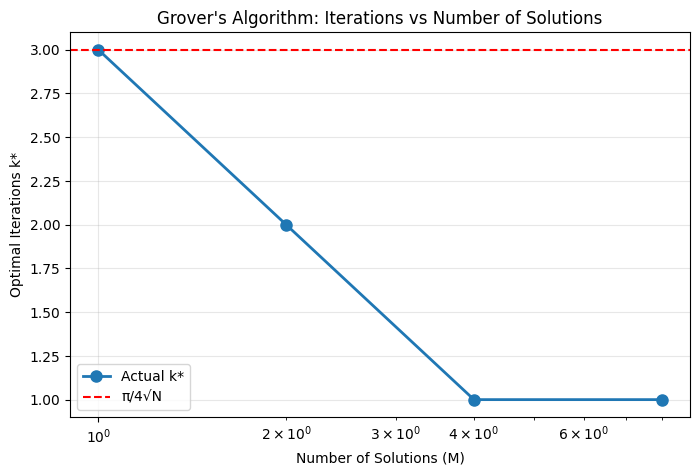


Success probabilities: [np.float64(0.9613189697265525), np.float64(0.9453124999999925), np.float64(0.9999999999999947), np.float64(0.4999999999999952)]


In [93]:
print("Exercise 4.2: Effect of M on iterations (N=16)\n")

n = 4
N = 2**n

Ms = [1, 2, 4, 8]
opt_iters = []
success_probs = []

print(f"{'M':>3} | {'Opt k':>5} | {'P(solution)':>11}")
print("-" * 28)

for M in Ms:
    targets = [format(i, f'0{n}b') for i in range(M)]

    qc = grovers_multi(n, targets)
    state = Statevector(qc)
    probs = np.abs(state.data)**2
    
    # Get optimal iterations used
    k_opt = int(np.floor(np.pi/4 * np.sqrt(N/M)))
    opt_iters.append(k_opt)
    
    # Get total probability of solutions
    success_prob = sum(probs[int(t, 2)] for t in targets)
    success_probs.append(success_prob)
    
    print(f"{M:3d} | {k_opt:5d} | {success_prob:11.4f}")

# TODO: Plot optimal iterations vs M
plt.figure(figsize=(8, 5))
plt.plot(Ms, opt_iters, 'o-', linewidth=2, markersize=8, label='Actual k*')
plt.axhline(int(np.pi/4 * np.sqrt(N)), color='red', linestyle='--', label='π/4√N')
plt.xlabel('Number of Solutions (M)')
plt.ylabel('Optimal Iterations k*')
plt.title('Grover\'s Algorithm: Iterations vs Number of Solutions')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xscale('log')
plt.show()

print(f"\nSuccess probabilities: {success_probs}")


 ---

 ## Bonus: Unknown Number of Solutions (10 points)



 When we don't know how many solutions $M$ exist, we can't compute

 the optimal iteration count. One strategy is **exponential search**:



 1. Try $k = 1$ iteration, measure. If solution found, stop.

 2. Try $k = 2$ iterations, measure. If solution found, stop.

 3. Try $k = 4$ iterations, measure. If solution found, stop.

 4. Continue doubling: $k = 1, 2, 4, 8, 16, \ldots$



 **Implement this strategy:**

 - Write `grovers_unknown(n, oracle_func, max_attempts=20)`

   - `oracle_func(qc, qubits)` applies the oracle to the circuit

   - For each attempt, build and measure the Grover circuit

   - A "solution" is verified by checking $f(x) = 1$ classically

 - Test on 4 qubits where the (hidden) target is $|1011\rangle$

 - Report: how many total oracle calls were needed to find the solution

In [91]:
def grovers_unknown(n, oracle_func, check_func, max_attempts=20):
    """
    Grover's search without knowing M.
    
    Parameters:
        n: number of qubits
        oracle_func: function(qc, qubits) that applies the oracle
        check_func: function(bitstring) -> bool, classical verification
        max_attempts: maximum number of doubling rounds
    
    Returns:
        (solution, total_oracle_calls) or (None, total_oracle_calls)
    """
    total_calls = 0
    
    # TODO: Implement exponential search strategy
    # Try k = 1, 2, 4, 8, ... iterations
    # For each k: build circuit, measure once, check if result is a solution
    k = 1
    while k <= max_attempts:
        # Build circuit with k iterations
        qc = QuantumCircuit(n, n)
        
        # Initialize superposition
        for i in range(n):
            qc.h(i)
        
        # Apply k Grover iterations
        diffusion = build_diffusion(n)
        
        for _ in range(k):
            oracle_func(qc, list(range(n)))
            qc.compose(diffusion, inplace=True)
            total_calls += 1
        
        # Measure once
        qc.measure(range(n), range(n))
        counts = run_circuit(qc, shots=1)
        measured = list(counts.keys())[0]
        
        # Check if solution
        if check_func(measured):
            return measured, total_calls
        
        # Double k and try again
        k *= 2
    
    return None, total_calls

# Define oracle and checker for |1011⟩
def hidden_oracle(qc, qubits):
    """Oracle for hidden target |1011⟩."""
    # TODO: Implement (use build_oracle or manual construction)
    oracle = build_oracle(4, '1011')
    qc.compose(oracle, qubits, inplace=True)

def hidden_check(bitstring):
    """Classical check: is this the solution?"""
    return bitstring == '1011'

# Run the search
n = 4
solution, calls = grovers_unknown(n, hidden_oracle, hidden_check)
print(f"Bonus: Unknown-M Grover's Search")
print(f"  Solution found: {solution}")
print(f"  Total oracle calls: {calls}")
print(f"  (Optimal would be ~{int(np.floor(np.pi/4 * np.sqrt(2**n)))} calls)")

Bonus: Unknown-M Grover's Search
  Solution found: 1011
  Total oracle calls: 3
  (Optimal would be ~3 calls)
